# WindOps AI Copilot — Features and Scoring Deep Dive

This notebook examines how raw SCADA signals are transformed into the risk score
that drives turbine prioritisation.

The analysis follows three layers:

1. **Feature engineering** — rolling statistics and proxy signals derived from hourly data
2. **Anomaly detection** — IsolationForest scores and persistence metrics
3. **Risk scoring** — aerodynamic, mechanical and anomaly subscores combined into a final priority

In [1]:
# ===============================
# SETUP
# ===============================

import sys
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

sys.path.append("..")

from matplotlib.patches import Patch
from src.data_generation import load_demo_scenario
from src.features import build_features, get_feature_columns
from src.anomaly import run_anomaly_pipeline
from src.risk import run_risk_pipeline
from src.impact import run_impact_pipeline
from src.prioritization import run_prioritization_pipeline

SCENARIO = "mixed"
PLOT_STYLE = "seaborn-v0_8-whitegrid"
plt.style.use(PLOT_STYLE)


# Load and run the full pipeline
df_hourly = load_demo_scenario(SCENARIO)
df_features = build_features(df_hourly)
df_anomaly, iso_model = run_anomaly_pipeline(df_features)
df_risk, risk_summary = run_risk_pipeline(df_anomaly)
loss_summary = run_impact_pipeline(df_risk)
priority = run_prioritization_pipeline(risk_summary, loss_summary)

fault_map = df_hourly.groupby("turbine_id")["fault_type"].first().to_dict()

print(f"Scenario : {SCENARIO}")
print(f"Turbines : {df_hourly['turbine_id'].nunique()}")
print(f"Hours    : {df_hourly['timestamp'].nunique()}")
print(f"Fault map:")
for tid, ft in sorted(fault_map.items()):
    if ft != "none":
        print(f"  {tid} → {ft}")

Scenario : mixed
Turbines : 20
Hours    : 720
Fault map:
  WTG-02 → gearbox_degradation
  WTG-07 → pitch_malfunction
  WTG-14 → sensor_drift


## 1. Feature Engineering

Each hourly row is enriched with rolling statistics computed per turbine.
The key features feeding the risk score are shown below.

In [2]:
# ===============================
# FEATURE CATALOGUE
# ===============================

feature_cols = get_feature_columns()
print("Feature columns produced by build_features():\n")
for f in feature_cols:
    print(f"  {f}")

Feature columns produced by build_features():

  power_gap_pct
  gap_roll_mean_24h
  gap_roll_max_24h
  nacelle_temp_roll_mean_24h
  nacelle_temp_trend_24h
  gear_oil_temp_roll_mean_24h
  gear_oil_temp_trend_24h
  vib_roll_mean_24h
  vib_trend_24h
  yaw_abs
  pitch_roll_std_24h


### 1.1 Power Gap — Rolling Mean

`gap_roll_mean_24h` is the primary aerodynamic signal: the average fraction of
expected power that was *not* generated over the last 24 hours.
Healthy turbines cluster near zero. Faulty turbines sit persistently higher.

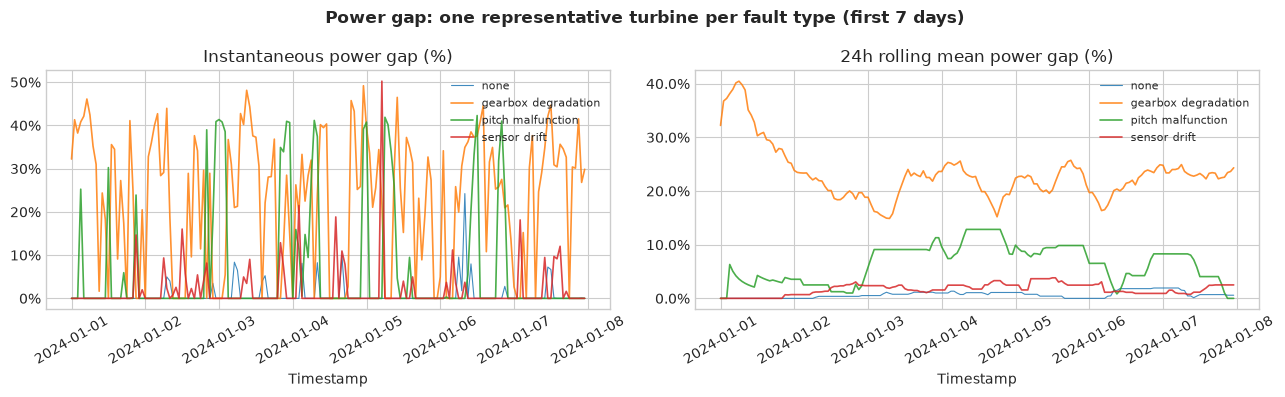

In [3]:
# ===============================
# POWER GAP ROLLING MEAN BY FAULT TYPE
# ===============================

df_features["fault_type"] = df_features["turbine_id"].map(fault_map)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for ax, col, label in [
    (axes[0], "power_gap_pct", "Instantaneous power gap (%)"),
    (axes[1], "gap_roll_mean_24h", "24h rolling mean power gap (%)"),
]:
    for fault, color, lw in [
        ("none", "steelblue", 0.8),
        ("gearbox_degradation", "tomato", 1.2),
        ("pitch_malfunction", "darkorange", 1.2),
        ("sensor_drift", "purple", 1.2),
    ]:
        subset = df_features[df_features["fault_type"] == fault]
        if subset.empty:
            continue
        sample = subset[subset["turbine_id"] == subset["turbine_id"].iloc[0]].head(168)
        ax.plot(
            sample["timestamp"], sample[col],
            linewidth=lw, alpha=0.85, label=fault.replace("_", " "),
        )

    ax.set_title(label)
    ax.set_xlabel("Timestamp")
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
    ax.tick_params(axis="x", rotation=30)
    ax.legend(fontsize=8)

plt.suptitle("Power gap: one representative turbine per fault type (first 7 days)",
             fontweight="bold")
plt.tight_layout()
plt.show()

### 1.2 Temperature Signals

`gear_oil_temp_roll_mean_24h` is the primary mechanical signal.
Gearbox degradation produces sustained temperature elevation.
Pitch and yaw faults do not affect temperatures — this is intentional and
reflects the physical fault signatures encoded in the simulation.

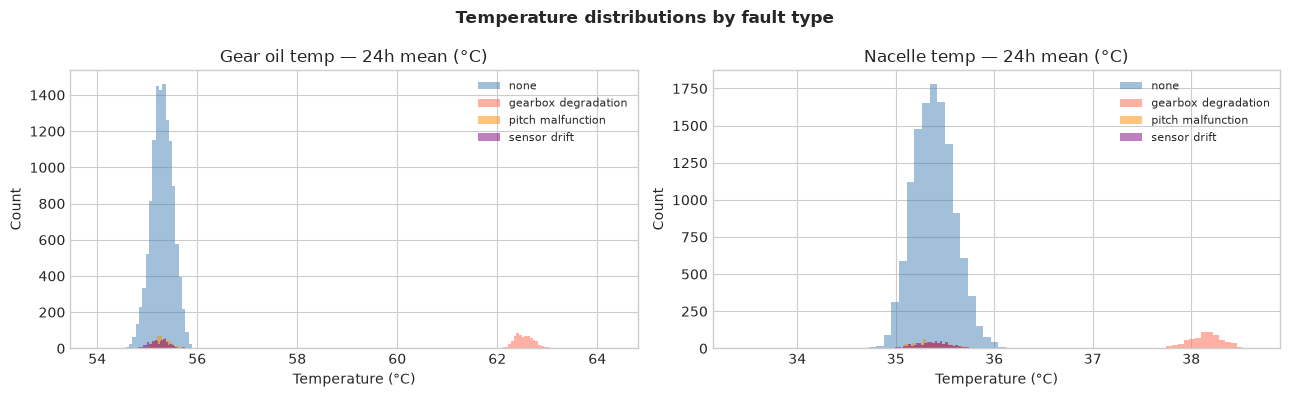

In [4]:
# ===============================
# TEMPERATURE BY FAULT TYPE — DISTRIBUTION
# ===============================

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

fault_colors = {
    "none": "steelblue",
    "gearbox_degradation": "tomato",
    "pitch_malfunction": "darkorange",
    "sensor_drift": "purple",
}

for ax, col, label in [
    (axes[0], "gear_oil_temp_roll_mean_24h", "Gear oil temp — 24h mean (°C)"),
    (axes[1], "nacelle_temp_roll_mean_24h", "Nacelle temp — 24h mean (°C)"),
]:
    for fault, color in fault_colors.items():
        subset = df_features[df_features["fault_type"] == fault][col].dropna()
        if subset.empty:
            continue
        ax.hist(subset, bins=40, alpha=0.5, color=color,
                label=fault.replace("_", " "))
    ax.set_title(label)
    ax.set_xlabel("Temperature (°C)")
    ax.set_ylabel("Count")
    ax.legend(fontsize=8)

plt.suptitle("Temperature distributions by fault type", fontweight="bold")
plt.tight_layout()
plt.show()

## 1.3 Fault Signal Reference Table

Each fault type leaves a distinct fingerprint across SCADA signals.
This table maps fault types to their expected signal behavior —
the design rationale behind the subscore weights.

| Fault type | Power gap | Gear oil temp | Anomaly score | Dominant subscore |
|---|---|---|---|---|
| `gearbox_degradation` | Sustained ↑ | Elevated ↑↑ | Moderate | Mechanical + Aerodynamic |
| `pitch_malfunction` | High at rated wind ↑ | Normal | Low–Moderate | Aerodynamic |
| `sensor_drift` | Noisy / ambiguous | Normal | High ↑↑ | Anomaly |
| `yaw_misalignment` | Sustained ↑ at all winds | Normal | Low | Aerodynamic |
| `none` (healthy) | Near zero | Normal | Low | — |



> This table informed the subscore family weights in `config.py`:
> aerodynamic (50%), mechanical (30%), anomaly (20%).
> Gearbox faults are the most dangerous and require two independent signals to confirm.

## 2. Anomaly Detection

IsolationForest is trained on the full feature set without using fault labels.
`anomaly_score` ranges from 0 (normal) to 1 (most anomalous).
`anomaly_persistence_24h` measures the fraction of flagged hours in the last 24h.

Note: sensor_drift is designed to be detectable primarily through anomaly scores,
since it adds noise rather than consistent thermal or power signatures.

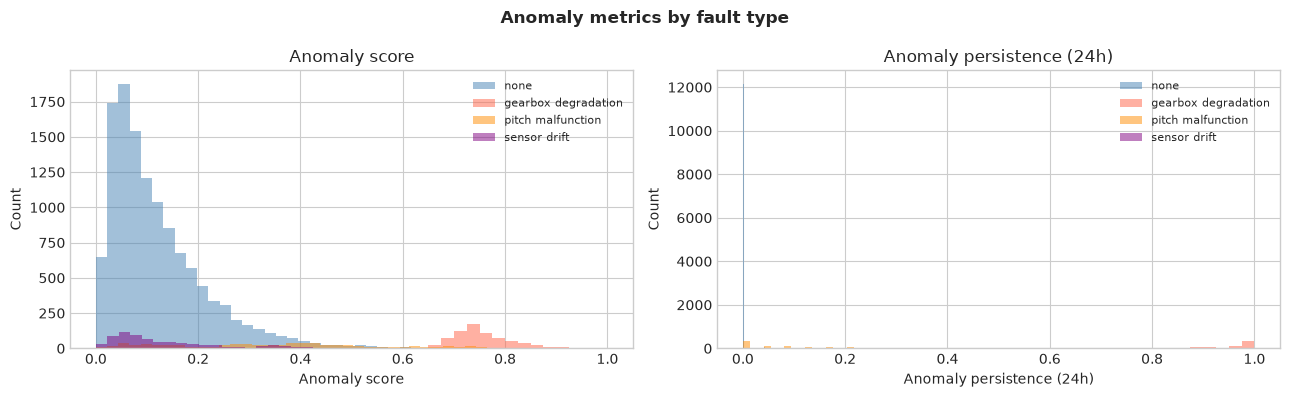

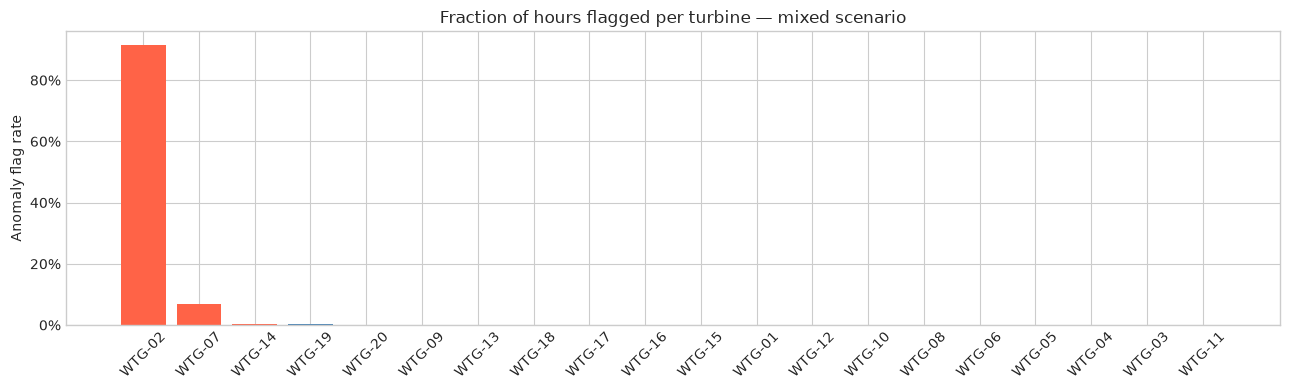

In [5]:
# ===============================
# ANOMALY SCORE DISTRIBUTION BY FAULT TYPE
# ===============================

df_anomaly["fault_type"] = df_anomaly["turbine_id"].map(fault_map)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for ax, col, label in [
    (axes[0], "anomaly_score", "Anomaly score"),
    (axes[1], "anomaly_persistence_24h", "Anomaly persistence (24h)"),
]:
    for fault, color in fault_colors.items():
        subset = df_anomaly[df_anomaly["fault_type"] == fault][col].dropna()
        if subset.empty:
            continue
        ax.hist(subset, bins=40, alpha=0.5, color=color,
                label=fault.replace("_", " "))
    ax.set_title(label)
    ax.set_xlabel(label)
    ax.set_ylabel("Count")
    ax.legend(fontsize=8)

plt.suptitle("Anomaly metrics by fault type", fontweight="bold")
plt.tight_layout()
plt.show()

# Flag rate per turbine
flag_rate = (
    df_anomaly.groupby("turbine_id")["anomaly_flag"]
    .mean()
    .reset_index()
    .sort_values("anomaly_flag", ascending=False)
)
flag_rate["fault_type"] = flag_rate["turbine_id"].map(fault_map)
flag_rate["is_faulty"] = flag_rate["fault_type"] != "none"

fig, ax = plt.subplots(figsize=(13, 4))
colors = flag_rate["is_faulty"].map({True: "tomato", False: "steelblue"})
ax.bar(flag_rate["turbine_id"], flag_rate["anomaly_flag"], color=colors)
ax.set_ylabel("Anomaly flag rate")
ax.set_title(f"Fraction of hours flagged per turbine — {SCENARIO} scenario")
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

## 3. Risk Score Decomposition

The risk score combines three subscores with fixed weights defined in `config.py`:

| Subscore | Weight | Primary signal |
|---|---|---|
| Aerodynamic (`aero_risk`) | 50% | Power gap, yaw proxy, pitch instability |
| Mechanical (`mech_risk`) | 30% | Gear oil temperature, vibration trend |
| Anomaly (`anomaly_risk`) | 20% | IsolationForest score and persistence |

Each subscore is a **hybrid**: 70% absolute (domain thresholds) + 30% relative (fleet-normalised).
This prevents a degraded fleet from masking its own critical turbines.

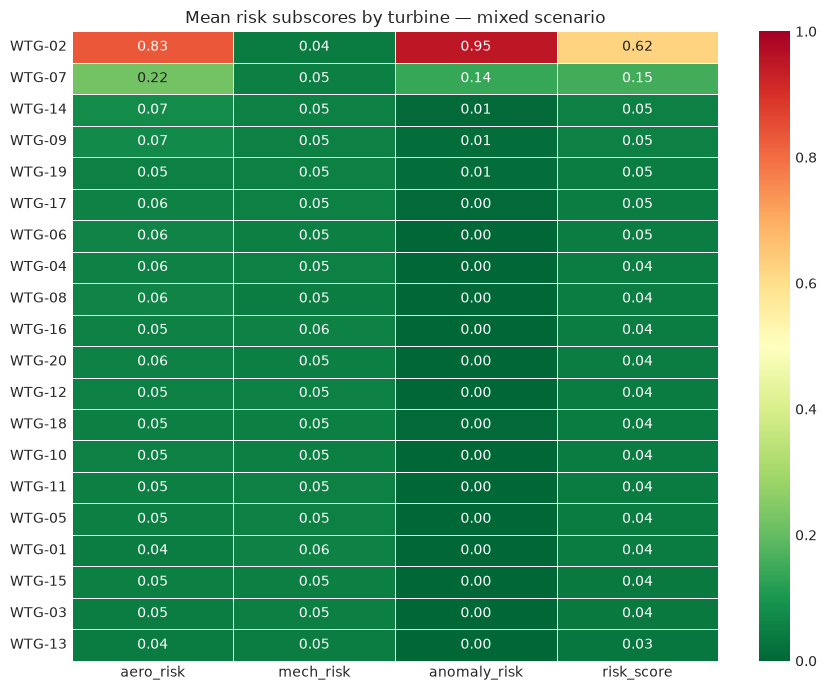

In [6]:
# ===============================
# SUBSCORE HEATMAP — MEAN VALUES
# ===============================

df_risk["fault_type"] = df_risk["turbine_id"].map(fault_map)

subscore_mean = (
    df_risk.groupby("turbine_id")[["aero_risk", "mech_risk", "anomaly_risk", "risk_score"]]
    .mean()
    .sort_values("risk_score", ascending=False)
)

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(
    subscore_mean,
    annot=True,
    fmt=".2f",
    cmap="RdYlGn_r",
    vmin=0,
    vmax=1,
    linewidths=0.4,
    ax=ax,
)
ax.set_title(f"Mean risk subscores by turbine — {SCENARIO} scenario")
ax.set_xlabel("")
ax.set_ylabel("")
plt.tight_layout()
plt.show()

### 3.1 Subscore Profiles by Fault Type

Each fault type leaves a different signature across subscores.
This is a key property for the agent: it can explain *why* a turbine is prioritised,
not just *that* it is.

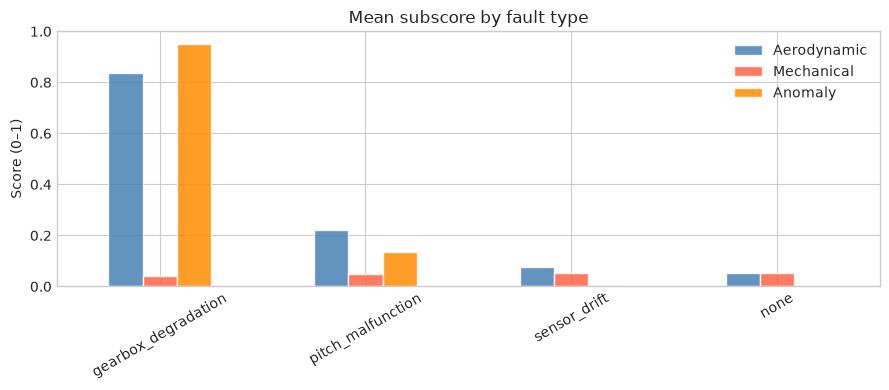


Mean subscores by fault type:
                     aero_risk  mech_risk  anomaly_risk  risk_score
fault_type                                                         
gearbox_degradation      0.835      0.042         0.951       0.622
pitch_malfunction        0.221      0.048         0.137       0.153
sensor_drift             0.074      0.051         0.006       0.054
none                     0.053      0.051         0.003       0.042


In [7]:
# ===============================
# MEAN SUBSCORE BY FAULT TYPE
# ===============================

subscore_by_fault = (
    df_risk.groupby("fault_type")[["aero_risk", "mech_risk", "anomaly_risk", "risk_score"]]
    .mean()
    .sort_values("risk_score", ascending=False)
)

fig, ax = plt.subplots(figsize=(9, 4))
subscore_by_fault[["aero_risk", "mech_risk", "anomaly_risk"]].plot(
    kind="bar",
    ax=ax,
    color=["steelblue", "tomato", "darkorange"],
    edgecolor="white",
    alpha=0.85,
)
ax.set_title("Mean subscore by fault type")
ax.set_ylabel("Score (0–1)")
ax.set_xlabel("")
ax.tick_params(axis="x", rotation=30)
ax.legend(["Aerodynamic", "Mechanical", "Anomaly"])
ax.set_ylim(0, 1)
plt.tight_layout()
plt.show()

print("\nMean subscores by fault type:")
print(subscore_by_fault.round(3).to_string())

## 3.2 Subscore Contribution per Turbine

How much does each subscore contribute to the final risk score?
Bars show the weighted contribution: `aero_risk × 0.50`, `mech_risk × 0.30`, `anomaly_risk × 0.20`.
The sum equals the final `risk_score` for each turbine.

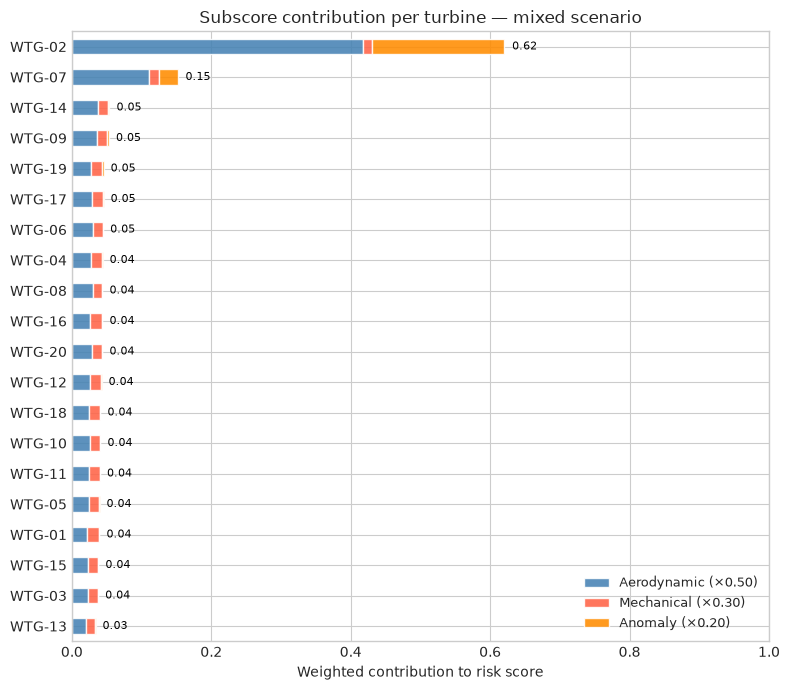

In [8]:
# ===============================
# SUBSCORE WEIGHTED CONTRIBUTION
# ===============================

from src.config import W_AERODYNAMIC, W_MECHANICAL, W_ANOMALY

contrib = subscore_mean.copy()
contrib["aero_contrib"]    = contrib["aero_risk"]    * W_AERODYNAMIC
contrib["mech_contrib"]    = contrib["mech_risk"]    * W_MECHANICAL
contrib["anomaly_contrib"] = contrib["anomaly_risk"] * W_ANOMALY
contrib = contrib.sort_values("risk_score", ascending=True)

fig, ax = plt.subplots(figsize=(8, 7))

contrib[["aero_contrib", "mech_contrib", "anomaly_contrib"]].plot(
    kind="barh",
    stacked=True,
    ax=ax,
    color=["steelblue", "tomato", "darkorange"],
    edgecolor="white",
    alpha=0.88,
)
ax.set_xlabel("Weighted contribution to risk score")
ax.set_title(f"Subscore contribution per turbine — {SCENARIO} scenario")
ax.set_ylabel("")
ax.set_xlim(0, 1)
ax.legend(
    ["Aerodynamic (×0.50)", "Mechanical (×0.30)", "Anomaly (×0.20)"],
    loc="lower right",
    fontsize=9,
)

# Annotate total risk score
for i, (idx, row) in enumerate(contrib.iterrows()):
    ax.text(
        row["risk_score"] + 0.01, i,
        f"{row['risk_score']:.2f}",
        va="center", fontsize=8, color="black",
    )

plt.tight_layout()
plt.show()

## 4. Priority Ranking

Final priority combines risk score (50%), energy loss (35%) and asset criticality (15%).
The ranking is what the agent consumes to generate action plans.

In [9]:
# ===============================
# PRIORITY RANKING WITH SUBSCORE BREAKDOWN
# ===============================

priority_full = priority.merge(
    risk_summary[
        ["turbine_id"]
    ],
    on="turbine_id",
    how="left",
)
priority_full["fault_type"] = priority_full["turbine_id"].map(fault_map)

display_cols = [
    "priority_rank", "turbine_id", "fault_type",
    "priority_score", "risk_score_mean",
    "aero_risk_latest", "mech_risk_latest", "anomaly_risk_latest",
    "loss_mwh_total",
]

print(f"Priority ranking — {SCENARIO} scenario:\n")
print(priority_full[display_cols].head(10).to_string(index=False))

Priority ranking — mixed scenario:

 priority_rank turbine_id          fault_type  priority_score  risk_score_mean  aero_risk_latest  mech_risk_latest  anomaly_risk_latest  loss_mwh_total
             1     WTG-02 gearbox_degradation        1.000000         0.621562          0.798168          0.022318                  1.0      284.465325
             2     WTG-07   pitch_malfunction        0.357732         0.153033          0.232925          0.017935                  0.0      117.904157
             3     WTG-08                none        0.161433         0.044065          0.086899          0.070934                  0.0       26.917408
             4     WTG-19                none        0.148505         0.045661          0.058857          0.046927                  0.0       20.968843
             5     WTG-12                none        0.146146         0.042729          0.049873          0.094563                  0.0       22.738825
             6     WTG-11                none       

## 5. Key Observations

- **Gearbox degradation** drives both aerodynamic and mechanical subscores: power loss is sustained and temperature is elevated.
- **Pitch malfunction** shows primarily as aerodynamic risk: power loss at high wind, no thermal signal.
- **Sensor drift** surfaces mainly through anomaly score: the noise it injects is statistically unusual even when power loss metrics are ambiguous.
- **Healthy turbines** score consistently low across all three subscores.

These fault signatures are the foundation for the agent's natural-language explanations in `03_agent_decisions.ipynb`.

## 6. Sensitivity Analysis — Risk Score Weights

How robust is the turbine ranking to changes in subscore weights?

We test four weight configurations and compare the resulting top-5 ranking.
If the ranking is stable across configurations, the prioritisation is robust.
If it shifts significantly, weight selection is a critical design decision.

| Configuration | Aerodynamic | Mechanical | Anomaly |
|---|---|---|---|
| Baseline (config.py) | 0.50 | 0.30 | 0.20 |
| Mechanical-heavy | 0.30 | 0.50 | 0.20 |
| Aerodynamic-heavy | 0.60 | 0.20 | 0.20 |
| Equal weights | 0.33 | 0.33 | 0.34 |

In [10]:
# ===============================
# SENSITIVITY ANALYSIS — WEIGHT CONFIGS
# ===============================

WEIGHT_CONFIGS = {
    "Baseline":          (0.50, 0.30, 0.20),
    "Mechanical-heavy":  (0.30, 0.50, 0.20),
    "Aerodynamic-heavy": (0.60, 0.20, 0.20),
    "Equal":             (0.33, 0.33, 0.34),
}

def recompute_risk_score(
    df: pd.DataFrame,
    w_aero: float,
    w_mech: float,
    w_anomaly: float,
) -> pd.Series:
    """Recompute risk score using alternative weights on existing subscores."""
    return (
        df["aero_risk"] * w_aero
        + df["mech_risk"] * w_mech
        + df["anomaly_risk"] * w_anomaly
    ).clip(0.0, 1.0)


# Build turbine-level means of subscores (already computed above)
base = subscore_mean[["aero_risk", "mech_risk", "anomaly_risk"]].copy()

ranking_tables = {}
for config_name, (w_a, w_m, w_an) in WEIGHT_CONFIGS.items():
    base[f"risk_{config_name}"] = recompute_risk_score(base, w_a, w_m, w_an)
    ranking_tables[config_name] = (
        base[f"risk_{config_name}"]
        .sort_values(ascending=False)
        .index.tolist()
    )

# --- Print ranking comparison ---
print(f"{'Turbine ranking by configuration (top 5)'}")
print(f"{'─'*70}")
header = f"{'Rank':<6}" + "".join(f"{k:<22}" for k in WEIGHT_CONFIGS)
print(header)
print("─" * 70)
for rank in range(min(5, len(base))):
    row = f"{rank+1:<6}"
    for config_name in WEIGHT_CONFIGS:
        tid = ranking_tables[config_name][rank]
        ft  = fault_map.get(tid, "none").replace("_", " ")[:14]
        row += f"{tid} ({ft})        "[: 22]
    print(row)
print("─" * 70)

Turbine ranking by configuration (top 5)
──────────────────────────────────────────────────────────────────────
Rank  Baseline              Mechanical-heavy      Aerodynamic-heavy     Equal                 
──────────────────────────────────────────────────────────────────────
1     WTG-02 (gearbox degradWTG-02 (gearbox degradWTG-02 (gearbox degradWTG-02 (gearbox degrad
2     WTG-07 (pitch malfunctWTG-07 (pitch malfunctWTG-07 (pitch malfunctWTG-07 (pitch malfunct
3     WTG-14 (sensor drift) WTG-09 (none)        WTG-14 (sensor drift) WTG-09 (none)        
4     WTG-09 (none)        WTG-14 (sensor drift) WTG-09 (none)        WTG-14 (sensor drift) 
5     WTG-19 (none)        WTG-17 (none)        WTG-06 (none)        WTG-19 (none)        
──────────────────────────────────────────────────────────────────────


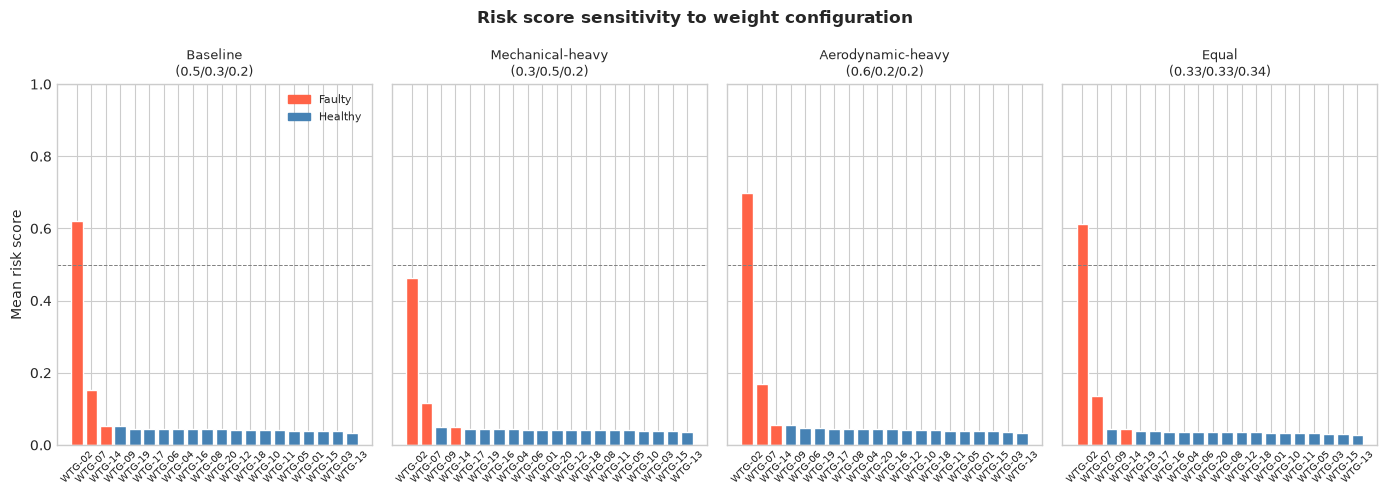

In [11]:
# ===============================
# SENSITIVITY — RISK SCORE SPREAD
# ===============================

fig, axes = plt.subplots(1, len(WEIGHT_CONFIGS), figsize=(14, 5), sharey=True)

for ax, (config_name, (w_a, w_m, w_an)) in zip(axes, WEIGHT_CONFIGS.items()):
    col = f"risk_{config_name}"
    scores = base[col].sort_values(ascending=False)
    bar_colors = [
        "tomato" if fault_map.get(tid, "none") != "none" else "steelblue"
        for tid in scores.index
    ]
    ax.bar(range(len(scores)), scores.values, color=bar_colors, edgecolor="white")
    ax.set_xticks(range(len(scores)))
    ax.set_xticklabels(scores.index, rotation=45, fontsize=7)
    ax.set_title(f"{config_name}\n({w_a}/{w_m}/{w_an})", fontsize=9)
    ax.set_ylim(0, 1)
    ax.axhline(0.5, color="gray", linestyle="--", linewidth=0.7)

axes[0].set_ylabel("Mean risk score")

axes[0].legend(
    handles=[
        Patch(color="tomato",    label="Faulty"),
        Patch(color="steelblue", label="Healthy"),
    ],
    fontsize=8,
)

plt.suptitle("Risk score sensitivity to weight configuration", fontweight="bold")
plt.tight_layout()
plt.show()

### Interpretation

- If the same turbines appear at the top across all configurations,
  the ranking is **robust** and the weight choice is less critical.
- If the top turbine changes depending on weights, it means two turbines
  have different fault signatures (one more mechanical, one more aerodynamic)
  and the weight choice is a **domain decision**, not an analytical one.

In production, weights would be calibrated against historical failure data
and validated with domain experts (e.g. higher mechanical weight for older
drivetrains, higher anomaly weight for fleets with known sensor issues).